# **Análisis Exploratorio de Datos (EDA)**
----

## **Módulos utilizados**

In [1]:
import pandas as pd

from utils.utils_description import describe_df
from utils.utils_hipotesis import *
from utils.utils_visualization import (
    plot_num_swkr_iqr, plot_categoricas, plot_cat_num_histograms,
    plot_categorical_numerical_relationship, plot_categorical_relationship, 
    temporal_rv_trans)

pd.set_option('display.max_columns', 20)

## **Bloques de contenido**
1. [Objetivos de esta fase](#1-objetivos-de-esta-fase)
2. [Carga de los datos](#2-carga-de-los-datos)
3. [Clasificación de las variables](#3-clasificación-de-las-variables)  
4. [Análisis univariante](#3-análisis-univariante)  
5. [Análisis bivariante](#5-análisis-bivariante)  
6. [Análisis temporal](#6-análisis-temporal)
7. [Correlaciones y contraste de hipótesis](#6-correlaciones-y-contraste-de-hipótesis)  

## 1. **Objetivos de esta fase**

En esta fase de **análisis exploratorio**, el objetivo es entender en profundidad los datos antes de construir el modelo. Se analizará tanto el dataset de transacciones (`df_clean`) como el dataset de modelado (`df_rfm`), con el fin de:

- Comprender la **distribución de las variables** numéricas y categóricas.
- Identificar **patrones de comportamiento** entre clientes que repiten compra y los que no.
- Detectar posibles problemas como **outliers o multicolinealidad** que deberán tratarse en la fase de preparación.
- Extraer **insights de negocio** relevantes para la presentación final.

## 2. **Carga de los datos**

In [2]:
df_rfm = pd.read_csv('./data/clean/online_retail_unique.csv', index_col=False) # Con Features RFM y target
df_all = pd.read_csv('./data/clean/online_retail_clean_all.csv', index_col=False) # Sin duplicados, nulos y con pedidos cancelados y no cancelados


## 3. **Clasificación de las variables**

Para poder realizar un análisis óptimo, en primer lugar, se calsificará las variables por variables categóricas y numéricas.

In [3]:
class_df = describe_df(df_all)
class_rfm = describe_df(df_rfm)

Clasificación sugerida para 779,425 filas, con un umbral para categórica de 10 sobre la cardinalidad y un umbral para númerica continua de 10.0 % sobre la cardinalidad relativa.
Clasificación sugerida para 5,279 filas, con un umbral para categórica de 10 sobre la cardinalidad y un umbral para númerica continua de 10.0 % sobre la cardinalidad relativa.


### 3.1. **Variables del `df` normal**

In [4]:
class_df

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,revenue,target
Columnas,,,,,,,,,,,
Tipo_Dato,int64,object,object,int64,object,float64,int64,object,bool,float64,float64
Nulos,0,0,0,0,0,0,0,0,0,0,27597
Nulos_%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5
Cardinalidad,36969,4631,5283,437,34585,665,5878,41,1,3734,2
Cardinalidad_%,4.74,0.59,0.68,0.06,4.44,0.09,0.75,0.01,0.0,0.48,0.0
Clasificacion_sugerida,Numerica_Discreta,Categorica,Categorica,Numerica_Discreta,Categorica,Numerica_Discreta,Numerica_Discreta,Categorica,Categorica,Numerica_Discreta,Categorica_Binaria


In [5]:
# Se convierte 'invoicedate' a datetime
df_all['invoicedate'] = pd.to_datetime(df_all['invoicedate'])

In [6]:
# Se dividen las variables en categóricas y numéricas
cat_df = [col for i, col in enumerate(class_df.columns) if class_df.iloc[(5),(i)].startswith('Categorica') and col not in ['stockcode', 'invoicedate', 'invoice', 'is_cancelled', 'target']] # Elimino target porque se analizará más tarde
                                                                                                                                                                                             # Elimino 'is_cancelled' porque con el tratamiento de quntity y pric > 0 se ha elimiando los cancelado
num_df = [col for i, col in enumerate(class_df.columns) if class_df.iloc[(5),(i)].startswith('Numerica')]

### 3.2. **Variables del `df_rfm`**

In [7]:
class_rfm

,customer_id,recency,frequency,monetary,avg_basket,n_products,n_countries,customer_age_days,avg_days_between_orders,target
Columnas,,,,,,,,,,
Tipo_Dato,int64,int64,int64,float64,float64,int64,int64,int64,float64,int64
Nulos,0,0,0,0,0,0,0,0,0,0
Nulos_%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cardinalidad,5279,593,83,5171,5216,415,2,592,1958,2
Cardinalidad_%,100.0,11.23,1.57,97.95,98.81,7.86,0.04,11.21,37.09,0.04
Clasificacion_sugerida,Numerica_Continua,Numerica_Continua,Numerica_Discreta,Numerica_Continua,Numerica_Continua,Numerica_Discreta,Categorica_Binaria,Numerica_Continua,Numerica_Continua,Categorica_Binaria


In [8]:
cat_rfm = [col for i, col in enumerate(class_rfm.columns) if class_rfm.iloc[(5),(i)].startswith('Categorica') and col not in ['target']]
num_rfm = [col for i, col in enumerate(class_rfm.columns) if class_rfm.iloc[(5),(i)].startswith('Numerica') and col not in ['customer_id']]

## 4. **Análisis univariante**

El análisis univariante estudia cada variable de forma **independiente**, sin relacionarla con el target. El objetivo es entender su distribución, detectar valores atípicos y anticipar posibles transformaciones necesarias antes del modelado.

### 4.1. **Variables numéricas**

Se analizan las distribuciones de las features RFM y las variables derivadas del comportamiento del cliente. Se prestará especial atención a la **asimetría (skewness)** ya que variables como `monetary` o `frequency` suelen presentar colas largas hacia la derecha, lo que puede perjudicar el rendimiento de ciertos algoritmos.

Analizando "recency":

Asimetría -> 0.66
	Esta variable tiene una distribución más o menos simétrica
Curtosis -> -0.58
	Esta variable tiene una distribución plana
-------------------------------------------------- 

Analizando "frequency":

Asimetría -> 11.06
	Esta variable tiene una asimetría positiva
	Esta sesgada hacia la derecha
Curtosis -> 196.67
	Esta variable tiene una distribución más picuda
	Probabilidad alta de outliers
-------------------------------------------------- 

Analizando "monetary":

Asimetría -> 23.76
	Esta variable tiene una asimetría positiva
	Esta sesgada hacia la derecha
Curtosis -> 739.21
	Esta variable tiene una distribución más picuda
	Probabilidad alta de outliers
-------------------------------------------------- 

Analizando "avg_basket":

Asimetría -> 36.38
	Esta variable tiene una asimetría positiva
	Esta sesgada hacia la derecha
Curtosis -> 1525.17
	Esta variable tiene una distribución más picuda
	Probabilidad alta de outliers
-----------------------

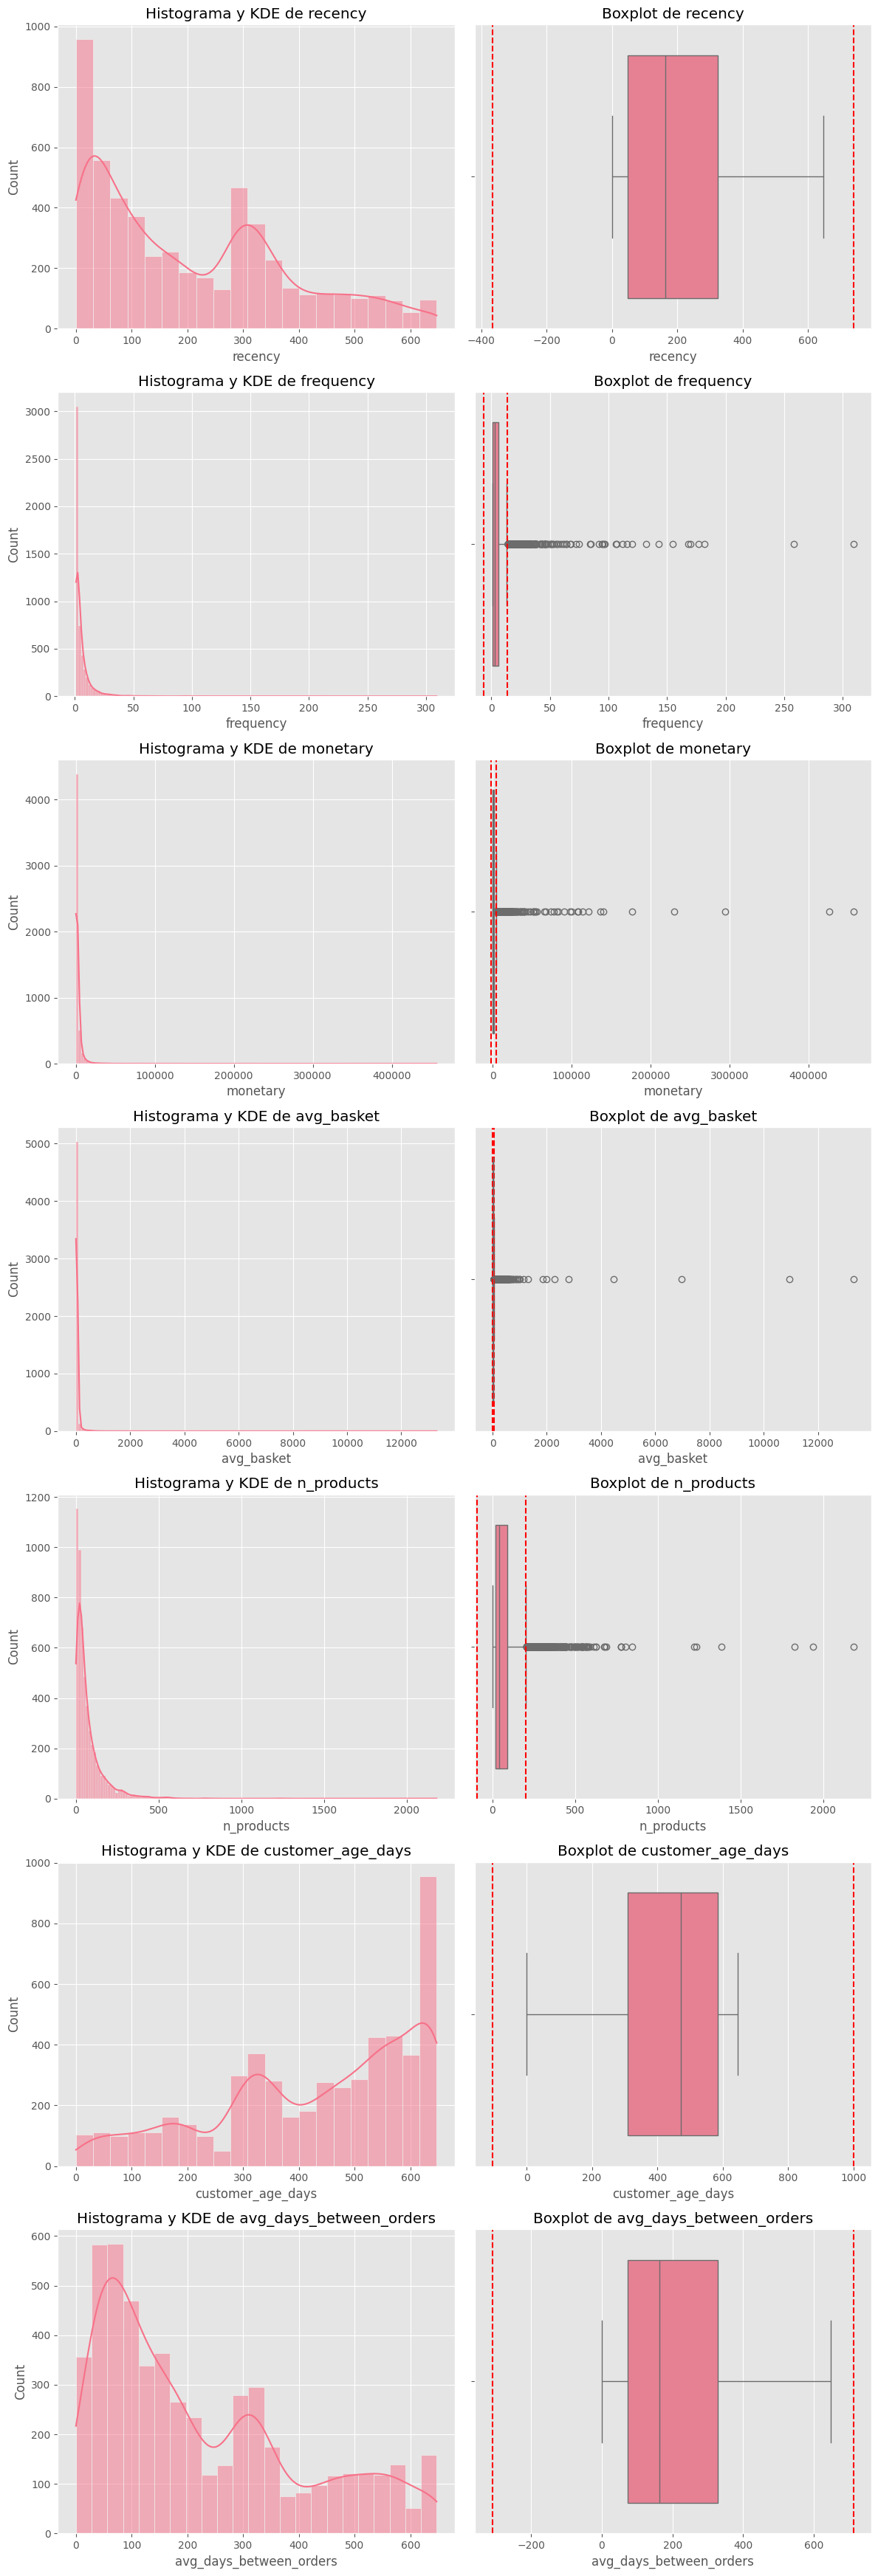


--- recency ---
Q1: 49.0
Q3: 325.0
IQR: 276.0
Lower bound: -365.0
Upper bound: 739.0
Número de outliers: 0

--- frequency ---
Q1: 1.0
Q3: 6.0
IQR: 5.0
Lower bound: -6.5
Upper bound: 13.5
Número de outliers: 459

--- monetary ---
Q1: 318.29
Q3: 2077.81
IQR: 1759.52
Lower bound: -2320.98
Upper bound: 4717.08
Número de outliers: 565

--- avg_basket ---
Q1: 11.54
Q3: 24.35
IQR: 12.81
Lower bound: -7.68
Upper bound: 43.57
Número de outliers: 589

--- n_products ---
Q1: 18.0
Q3: 92.0
IQR: 74.0
Lower bound: -93.0
Upper bound: 203.0
Número de outliers: 415

--- customer_age_days ---
Q1: 310.0
Q3: 586.0
IQR: 276.0
Lower bound: -104.0
Upper bound: 1000.0
Número de outliers: 0

--- avg_days_between_orders ---
Q1: 73.93
Q3: 329.0
IQR: 255.07
Lower bound: -308.68
Upper bound: 711.61
Número de outliers: 0


In [9]:
plot_num_swkr_iqr(df_rfm, num_rfm)

*Observaciones*
- `recency` y `avg_days_between_orders`:
    - Distribución plana sin outliers.
    - Esto es habitual: los días entre eventos tienden a distribuirse de forma más uniforme en datasets de retail.

- `frequency`, `monetary`, `avg_basket` y `n_products`:
    - **Análisis de Asimetría y la Curtosis** -> Indican que la distribución tiene una asimetría positiva sesgada hacia la derecha y tienen una alta probabilidad de outliers. 
    - **Análisis de los histogramas, boxplots e IQR** -> Se confirman los outliers:
        - En `frequency` a partir de 13.5 teniendo un número total de 459 outliers.
        - En `monetary` a partir de 4715.38 con 565 outliers.
        - En `avg_basket` a partir de 43.59 con 589 outliers.
        - En `n_products` a partir de 203.0 con 415 outliers.
    - Esto indica que existe un núcleo mayoritario de clientes con comportamiento modesto y una minoría de clientes de alto valor con compras muy frecuentes o de gran volumen

- `customer_age_days`:
    - **Análisis de Asimetría y la Curtosis** -> Indican que la distribución tiene una asimetría negativa sesgada hacia la izquierda teniendo una distribución plana, es decir, sin outliers
    - **Análisis de los histogramas, boxplots e IQR** -> Se confirma lo anterior
    - Indica que la mayoría de clientes llevan bastante tiempo en el dataset, con pocos clientes muy nuevos



### 4.2. **Variables categóricas**

Se analiza el dataset `df_all`, ya que cuenta con todos los registros (limpios de duplicados y de nulos en `customer_id`) para explorar la distribución de variables como el **país de origen**, la **estacionalidad** de las compras o los **productos más vendidos**. Además se obsrvará la distribución de los pedidos cancelados frente a los no cancelados y la distribución del Target.

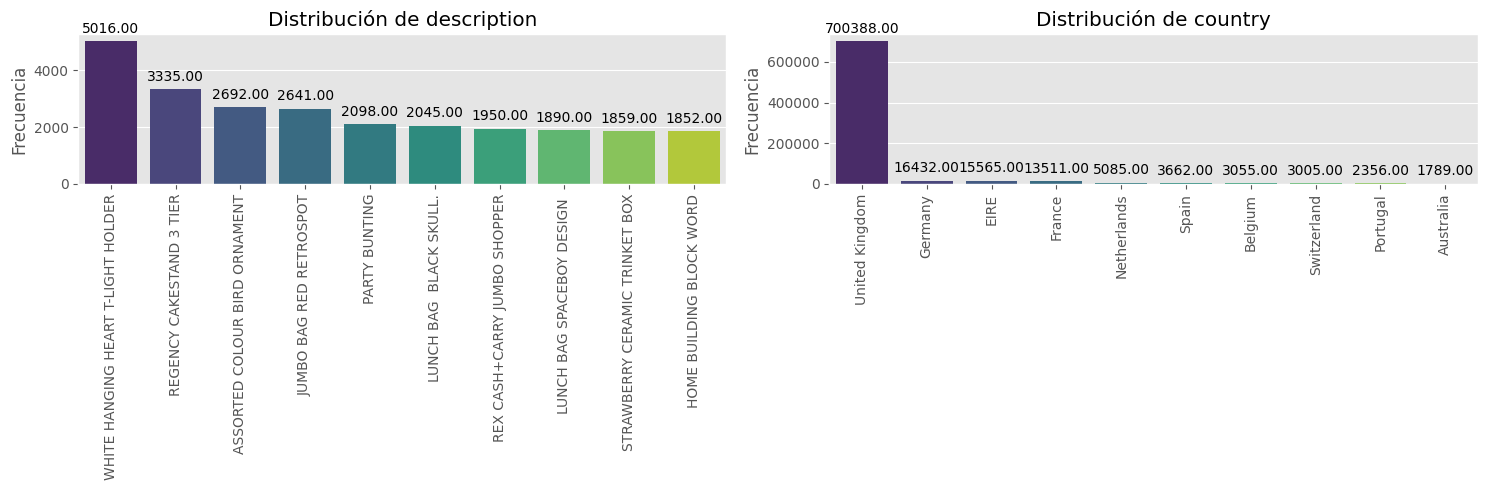

In [10]:
plot_categoricas(df_all, cat_df, mostrar_valores=True)

***Observaciones***:  
En estas gráficas se puede observar:
- El **top 10 de los productos más vendidos**: Lo que más se compra son lámparas blancas en forma de corazón
- El **top 10 de los países** donde más se vende, el cual es Reino Unido teniendo una gran diferencia con respecto al segundo (Alemania)

## 5. **Análisis bivariante**

El análisis bivariante estudia la **relación entre cada variable y el target**, con el objetivo de identificar qué features tienen mayor poder discriminante para predecir si un cliente va a repetir compra o no. Estos hallazgos anticipan qué variables serán más relevantes en el modelo.

### 5.1. **Variables numéricas vs Target**

Se compara la distribución de cada feature RFM entre clientes que repitieron compra (target=1) y los que no (target=0). Se utilizan **boxplots y distribuciones superpuestas** para visualizar si existe separación clara entre ambos grupos, lo que indicaría alto poder predictivo de esa variable.


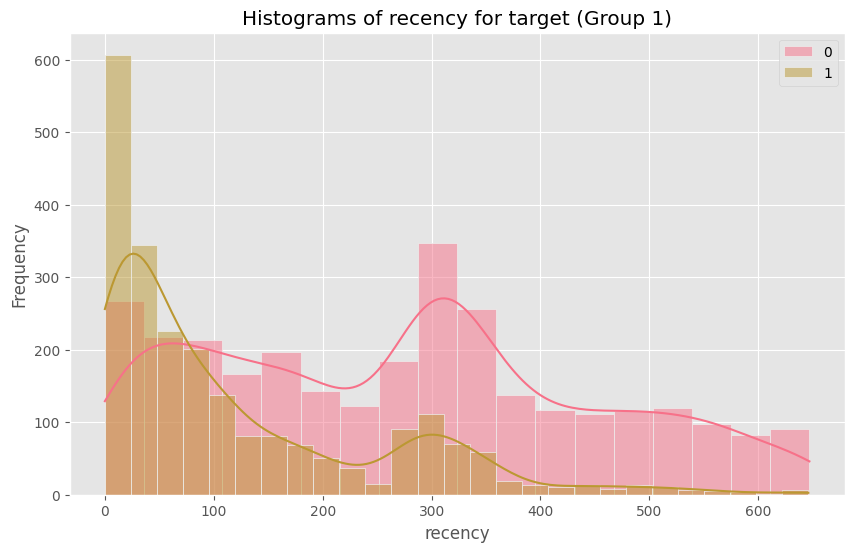

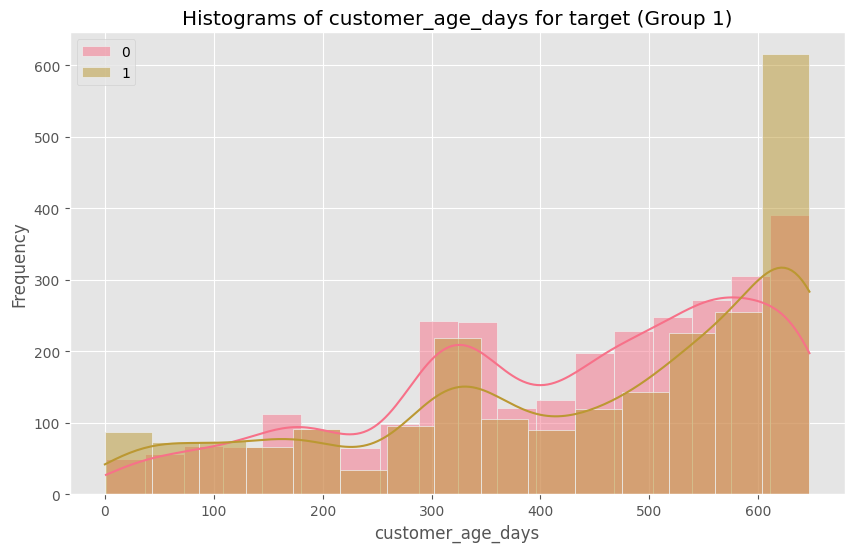

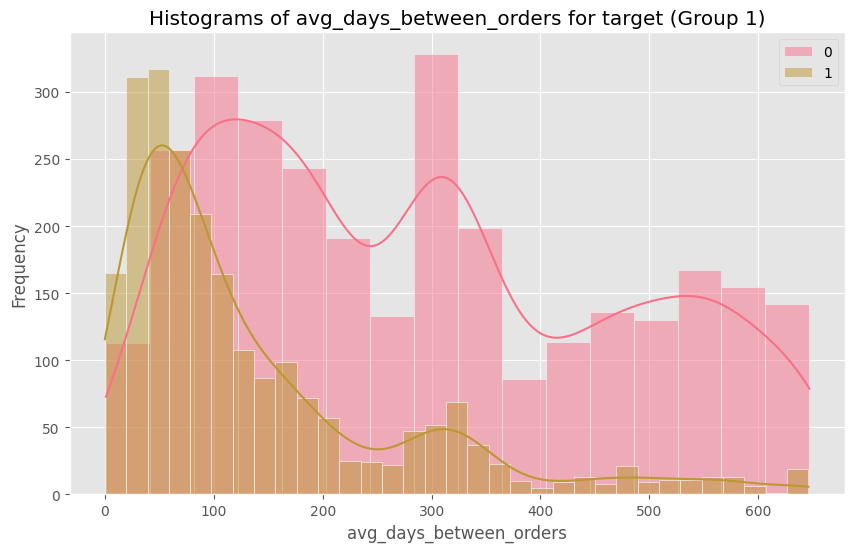

In [11]:
for col in ['recency', 'customer_age_days', 'avg_days_between_orders']:
    plot_cat_num_histograms(df_rfm, 'target', col, group_size=2)
    # if col in ['frequency', 'monetary', 'avg_basket', 'n_products']

***Obsevaciones***:
- `recency`: Como esta variable es hasta la fecha de corte, es decir, antes de esos últimos 3 meses, refleja que la cantidad de los días transcurridos desde la última compra es mayor en clientes que no vuelven a comprar. Esta consecuencia es lógica, ya que si no vuelven a comprar, esa diferencia es mayor.

- `customer_age_days`: En la gráfica hay varios cruces, al principio y al final, indicando que puede llegar a influir la antigüedad de los clientes en la tasa de recompra.

- `avg_days_between_orders`: Hay un cruce significativo entre 90 y 100 días dejando claro que a cuanto mayor es la diferencia de días entre pedidos, mayor es la tasa de NO compra.

- `frequency`, `monetary`, `avg_basket` y `n_products`: Al tener una asimetría sesgada a la derecha, se va a analizar con barplots.

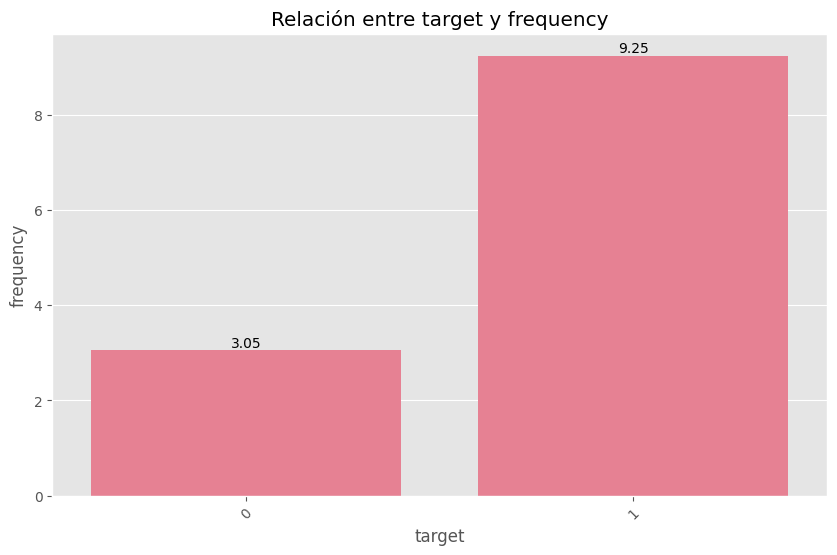

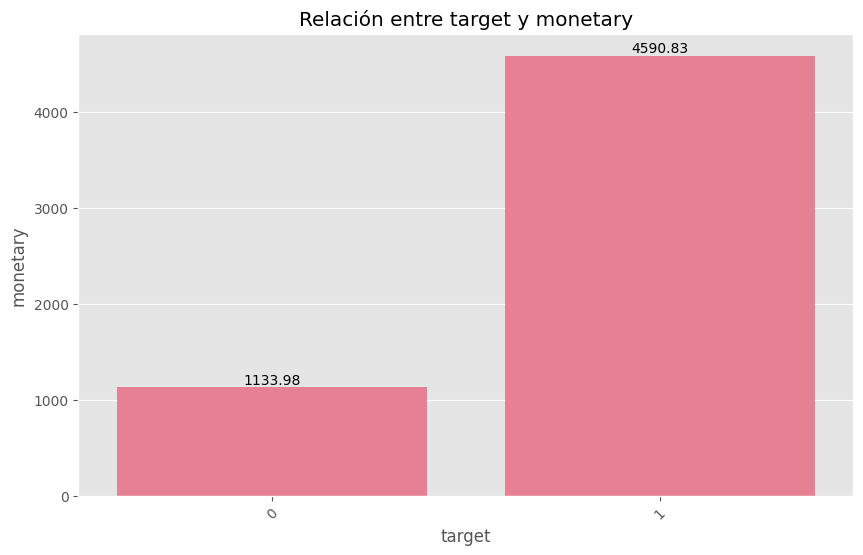

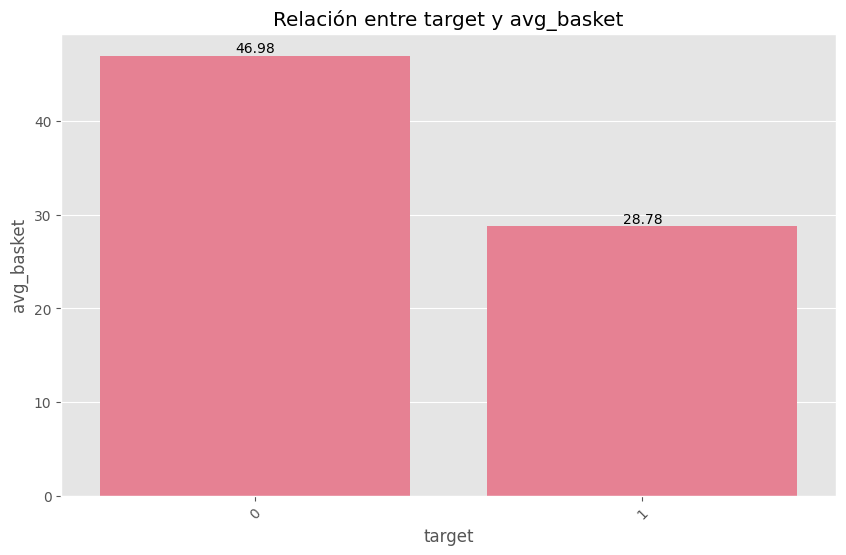

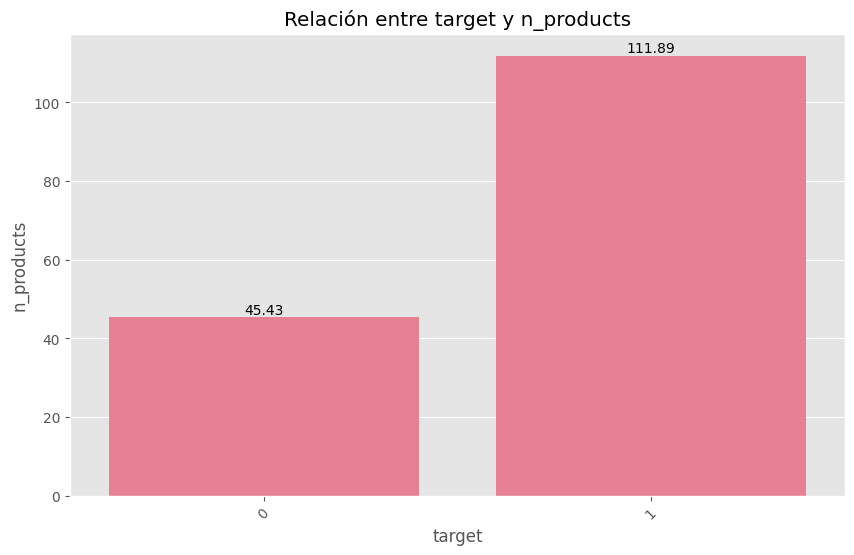

In [12]:
plot_categorical_numerical_relationship(df_rfm, 'target', ['frequency', 'monetary', 'avg_basket', 'n_products'])

***Obsevaciones***:

- `frequency`, `monetary` y `n_products`: El número de facturas únicas, el gasto total y el número de productos comprados es mayor en clientes que sí vuelven a comprar, por lo que generan más facturas, más gasto en los clientes y más cantidad de productos comprados.

- `avg_basket`: El ticket medio por producto es mayor en clientes que no vuelven a comprar, esto significa que esos clientes han comprado más.

Posibles relaciones con el **target**: `recency`, `customer_age_days`, `avg_days_between_orders`, `frequency`, `monetary`, `avg_basket` y `n_products`

### 5.2. **Variables categóricas vs Target**

Se analiza la **tasa de recompra** según variables categóricas como el país de origen o si alguna vez han cancelado el pedido. El objetivo es detectar grupos de clientes con comportamientos de recompra significativamente distintos.

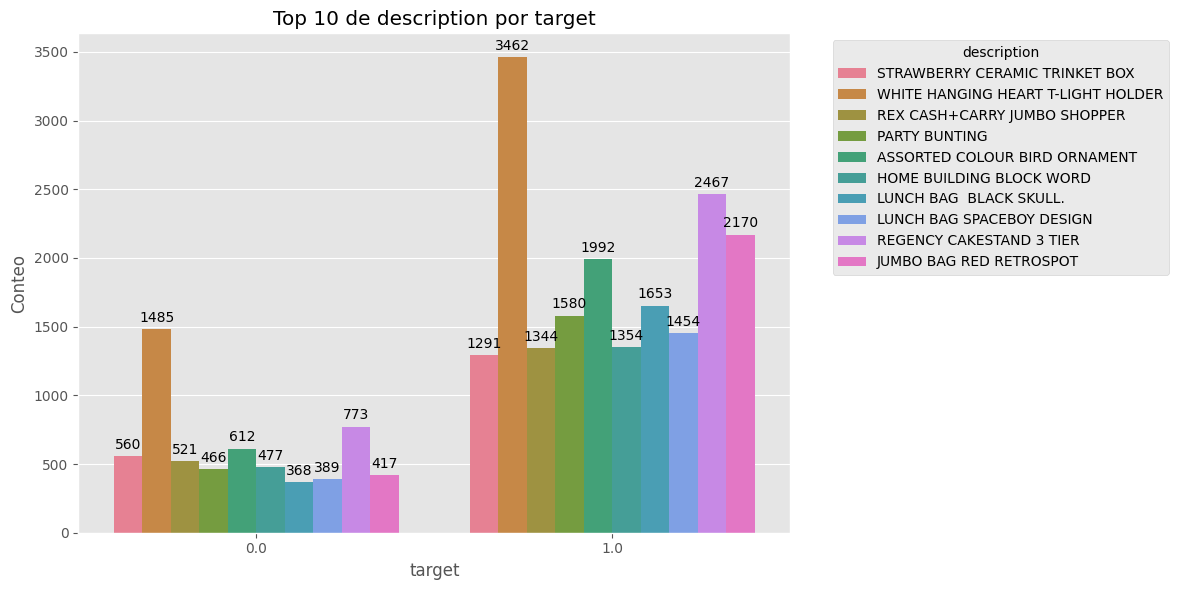

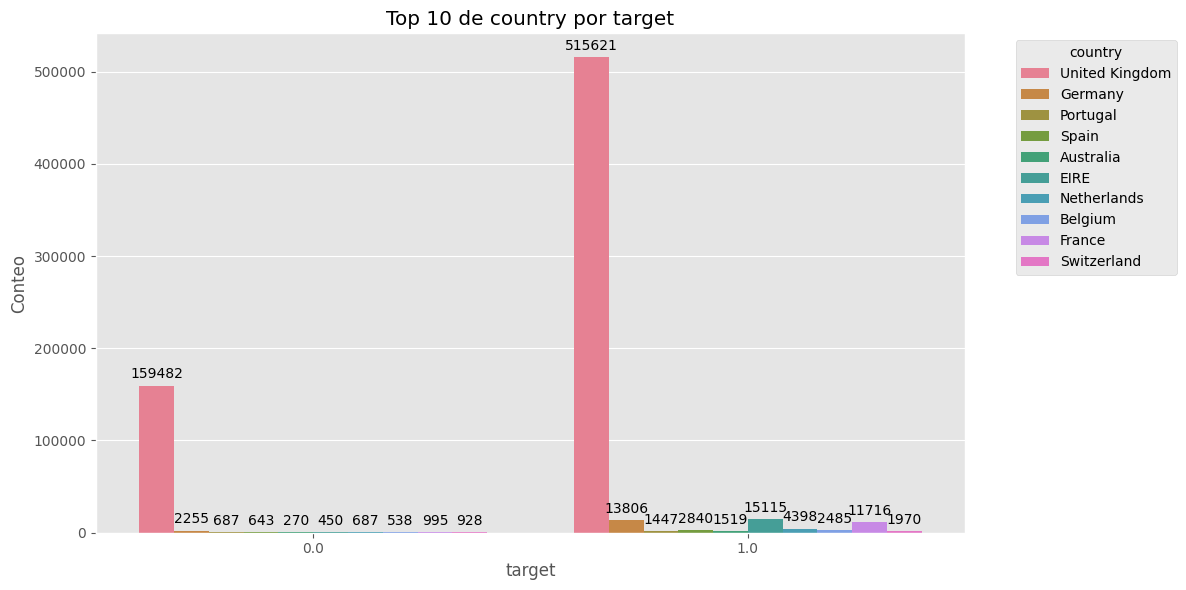

In [13]:
plot_categorical_relationship(df_all, 'target', cat_df)

***Observaciones***:  
Analizando las 3 variables categóricas, se puede deducir, visualmente, que ninguna tienen relación aparente contra el Target, es decir, no influye en qué país se ha realizado la compra, ni los productos que se han adquirido y si se ha cancelado un pedido o no.

## 6. Análisis temporal

Se analiza la evolución mensual del **volumen de ventas (revenue)** y el **número de transacciones** a lo largo de los 24 meses del dataset. 

El objetivo es detectar patrones de **estacionalidad** que puedan ser relevantes para el negocio, como picos en fechas clave o caídas sostenidas 
que justifiquen acciones de retención.

Se marca además la **línea de corte temporal** que separa el período de  observación del período de validación, para contextualizar visualmente la construcción del target.

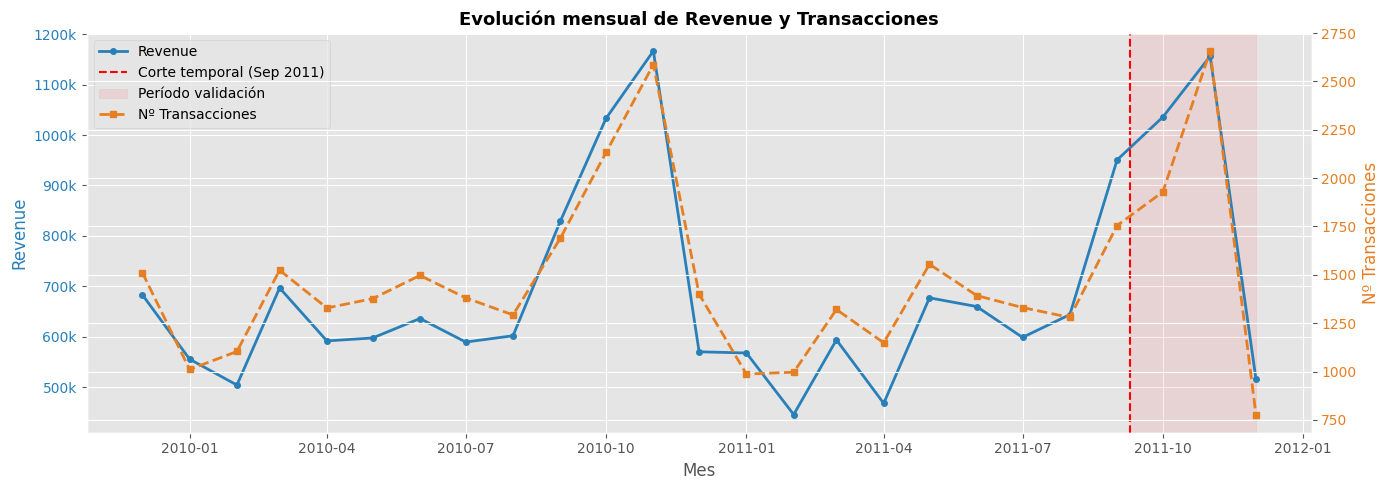

In [14]:
temporal_rv_trans(df_all)

***Conclusiones***:
- Todo el éxito del año se concentra en octubre, noviembre y diciembre. El resto del año es "temporada baja", con una caída muy fuerte en enero tras las fiestas.

- `revenue` y las transacciones se mueven de manera similar, esto significa que los ingresos suben solo si sube el número de ventas. Por lo que los beneficios son porque la gente compra más veces.

- El final de la gráfica (2011) con el principio (2010), verás que las montañas son más altas. El negocio tiene más fuerza y más clientes en su segundo año que en el primero.

## 7. **Correlaciones y contraste de hipótesis**

En este apartado se analiza, por un lado, la **estructura de correlaciones**  entre las features numéricas para detectar posibles problemas de multicolinealidad antes del modelado. Por otro lado, se realizan **contrastes de hipótesis** para determinar si las diferencias observadas entre clientes 
que repiten compra y los que no son **estadísticamente significativas** o pueden deberse al azar.

### 7.1. **Heatmap de correlaciones**

Se visualiza la matriz de correlaciones entre todas las features numéricas. Correlaciones muy altas entre dos features (>0.8) pueden indicar multicolinealidad, lo que podría perjudicar a modelos lineales y deberá tenerse en cuenta en la fase de preparación.

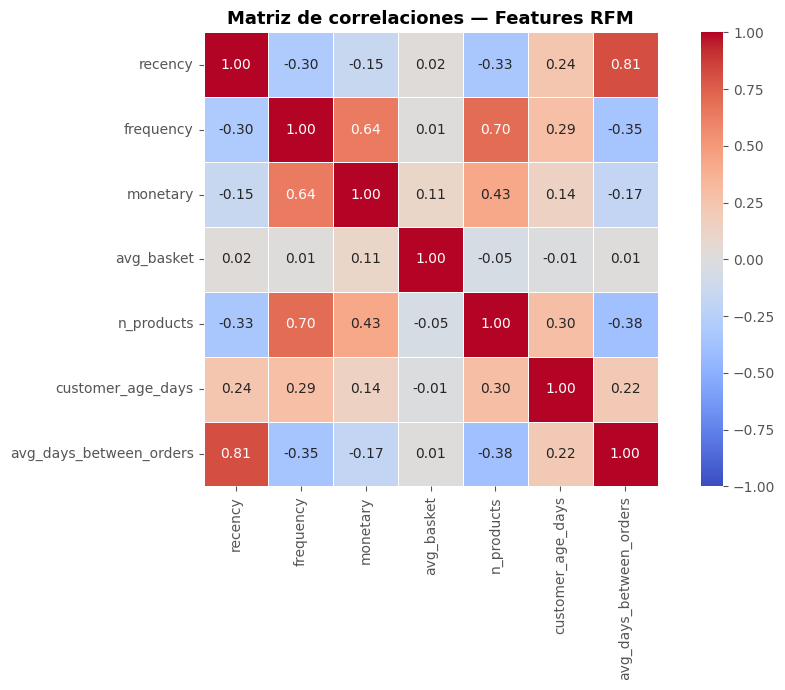

In [15]:
heatmap_corr(df_rfm, num_rfm)


***Observaciones***:

- `recency` vs `avg_days_between_orders` (0.82): Esta es la correlación más alta. Tiene todo el sentido lógico: si un cliente suele dejar pasar mucho tiempo entre compras, es muy probable que su `recency` (días desde la última compra) también sea alta.

- `frequency` vs `n_products` (0.70): Indica que los clientes que compran con más frecuencia también tienden a comprar una mayor variedad o cantidad total de productos.

- `frequency` vs `monetary` (0.64): Los clientes que vuelven más seguido son, por lo general, los que más dinero dejan en el negocio. No es una regla perfecta, pero es una tendencia sólida.

- `recency` vs `frequency` (-0.30) y `n_products` (-0.34): Esto sugiere que a medida que pasa más tiempo desde la última compra (recency sube), la frecuencia de compra del cliente tiende a ser menor. Es un indicador de churn (abandono): los clientes que dejan de venir pierden su ritmo de frecuencia.

- Llama mucho la atención que `avg_basket` (el valor promedio de la cesta) tiene valores cercanos a 0 con casi todo. Esto significa que el tamaño de la compra individual (cuánto gastan en un solo ticket) no depende de si el cliente es antiguo, si viene seguido o si hace mucho que no compra. Por lo que no se puede predecir cuánto va a gastar alguien hoy basándose solo en su historial de frecuencia.

<Figure size 1000x700 with 0 Axes>

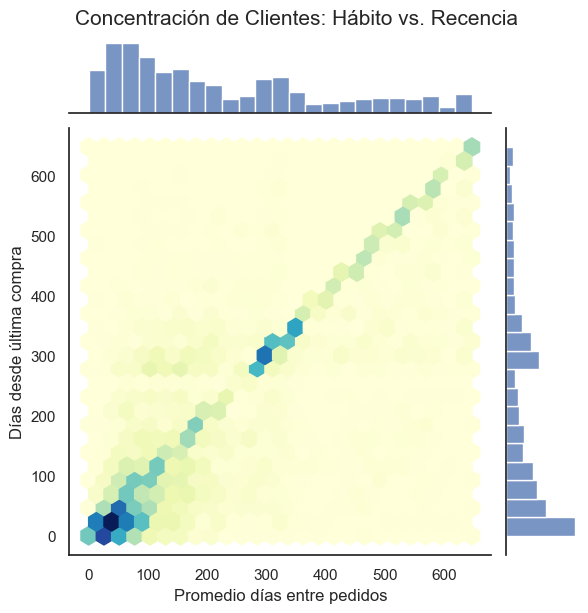

In [27]:
# Visual para la presentación
plt.figure(figsize=(10, 7))
sns.set_style("white")

# jointplot para ver la relación y las distribuciones individuales
g = sns.jointplot(
    data=df_rfm, 
    x='avg_days_between_orders', 
    y='recency',
    kind="hex", 
    cmap="YlGnBu", 
    gridsize=25
)

g.fig.suptitle('Concentración de Clientes: Hábito vs. Recencia', y=1.02, fontsize=15)
g.set_axis_labels('Promedio días entre pedidos', 'Días desde última compra', fontsize=12)

plt.show()

### 7.2. **Contraste de hipótesis - Variables numéricas**

Dado que las variables RFM **no siguen una distribución normal** (presentan fuerte asimetría), se utiliza el test no paramétrico de **Mann-Whitney U** en lugar del t-test. Este test compara si la distribución de cada feature es significativamente distinta entre target=0 y target=1.

- **H₀**: No existe diferencia significativa entre ambos grupos
- **H₁**: Sí existe diferencia significativa entre ambos grupos
- **Nivel de significancia**: α = 0.05

In [16]:
df_hipo_num = hipo_num_target(df_rfm, 'target', num_rfm)

In [17]:
df_hipo_num

,Feature,Estadístico U,p-valor,Significativa
6,avg_days_between_orders,5257075.0,1.416255e-244,Sí ✅
0,recency,5224228.5,5.718729e-236,Sí ✅
1,frequency,1718318.5,2.815739e-219,Sí ✅
2,monetary,1770234.0,2.290869e-199,Sí ✅
4,n_products,1889088.0,4.845770e-172,Sí ✅
5,customer_age_days,3090787.5,1.304238e-09,Sí ✅
3,avg_basket,3358201.5,2.320931e-01,No ❌


***Observaciones***:
- Se puede concluir que se rechaza la hipótesis nula en todas las variables excepto en `avg_basket` ya que su p-valor es superior a 0.05.

In [18]:
# Se guarda en una variable las features numéricas que se vaya a utilizar en el modelado
features_num = [var for var in df_hipo_num['Feature'] if var != 'avg_basket']
features_num

['avg_days_between_orders',
 'recency',
 'frequency',
 'monetary',
 'n_products',
 'customer_age_days']

### 7.3. **Contraste de hipótesis - Variables categóricas**

Para las variables categóricas se utiliza el test **Chi-cuadrado (χ²)**, que evalúa si existe una asociación estadísticamente significativa entre cada variable categórica y el target.

- **H₀**: La variable categórica es independiente del target
- **H₁**: Existe asociación entre la variable categórica y el target
- **Nivel de significancia**: α = 0.05

In [19]:
df_hipo_cat = hipo_cat_target(df_all, 'target', cat_df)

In [20]:
df_hipo_cat

,Feature,Chi²,p-valor,Grados libertad,Significativa
0,description,36177.95,0.0,5280,Sí ✅
1,country_mode,10112.39,0.0,10,Sí ✅


***Observaciones***:
- Se puede concluir que se rechaza la hipótesis nula en todas las variables excepto en `is_cancelled` ya que su p-valor es superior a 0.05.

In [21]:
# Se guarda en una variable las features categóricas que se vaya a utilizar en el modelado
features_cat = [var for var in df_hipo_cat['Feature'] if var != 'is_cancelled']
features_num

['avg_days_between_orders',
 'recency',
 'frequency',
 'monetary',
 'n_products',
 'customer_age_days']

## 8. **Conclusiones e Insights**

La **base de clientes** presenta una **estructura** claramente **bimodal**: existe un núcleo mayoritario de clientes con un comportamiento de compra modesto (pocas facturas, gasto bajo, catálogo reducido) y una minoría de clientes de alto valor que compran con mucha más frecuencia, gastan significativamente más y diversifican más su cesta. Esta segmentación natural es la base sobre la que se construirá la estrategia de fidelización y retención.

El **mercado principal** es el Reino Unido, con una diferencia muy significativa respecto al resto de países. Alemania es el segundo mercado, aunque a mucha distancia. Las cancelaciones representan un volumen marginal y no tienen impacto relevante en el comportamiento de recompra.

El **análisis estadístico** (*test de Mann-Whitney*) confirma que seis variables discriminan de forma significativa entre clientes que repiten y los que no:
- `recency`: El tiempo desde la última compra es el indicador más intuitivo. Los clientes que llevan más días sin comprar antes del período de validación son los que con mayor probabilidad no vuelven. Es decir, si un cliente lleva mucho tiempo sin aparecer, la probabilidad de perderlo es alta. Es la señal de alerta más directa para activar campañas de reactivación.
- `avg_days_between_orders`: El ritmo habitual del cliente importa. Existe un punto de inflexión claro en torno a los 90–100 días entre pedidos: por encima de ese umbral, la probabilidad de no recompra aumenta notablemente. Clientes con ciclos de compra largos son estructuralmente más frágiles frente al abandono.
- `frequency` y `monetary`: Más compras y más gasto predicen fidelidad. Los clientes que repiten compra tienen una mediana de facturas y un gasto total significativamente mayores. Esto quiere decir que quien más compra, más probabilidad tiene de seguir comprando.
- `n_products` — La diversificación del catálogo es una señal positiva. Los clientes que han comprado una mayor variedad de productos son más propensos a volver. Un cliente que ha explorado el catálogo tiene más "razones" para regresar.
- `customer_age_days`: La antigüedad aporta información, aunque de forma no lineal. Los clientes con más tiempo en la plataforma muestran patrones diferenciados de recompra en los extremos (clientes muy nuevos y clientes muy veteranos). La relación no es tan limpia como en recency o frequency, pero el historial de relación con la marca sí tiene valor predictivo.
- `avg_basket`: El tamaño del ticket individual no determina la fidelidad. Paradójicamente, el gasto medio por visita es ligeramente mayor en clientes que no vuelven. Esto sugiere que hay clientes que hacen una compra grande puntual (quizás por una ocasión especial) y no regresan. No se debe confundir un ticket alto con un cliente fiel. El volumen acumulado importa; el ticket puntual, no.
- El `país` y las `cancelaciones` no influyen en la recompra. Aunque la distribución geográfica es muy desigual, el hecho de que un cliente sea del Reino Unido o de otro país no predice si volverá a comprar. Lo mismo ocurre con las cancelaciones: haber cancelado un pedido en el pasado no es un factor discriminante.

Existen **correlaciones relevantes** que el equipo de negocio debe conocer:

- Recency y cadencia de compra van de la mano (correlación 0.82): un cliente que tarda mucho entre pedidos inevitablemente acumula más días desde su última compra. Son dos caras del mismo problema.
- Frecuencia, gasto y variedad de productos forman un grupo cohesionado: quien compra más seguido tiende a gastar más y a explorar más el catálogo. Esto valida que los programas de fidelización que incentivan visitas recurrentes tienen un efecto multiplicador sobre el valor del cliente.
- La señal de abandono más temprana es la caída en frecuencia: a medida que recency sube (más tiempo sin comprar), la frecuencia histórica del cliente tiende a ser menor. Un cliente que empieza a espaciar sus visitas está en riesgo.